In [ ]:
!pip install optuna koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
import koreanize_matplotlib

# 데이터 전처리(데이터 분리, 스케일링, 인코딩, 파이프라인(데이터 누수 방지)관련
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 모델 학습 및 성능 평가 관련
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Optuna 관련
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)
# Optuna 로깅 레벨 조절
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Optuna 버전: {optuna.__version__}")

Optuna 버전: 4.7.0


In [ ]:
# 데이터 로드 & 확인
# train 데이터
calories_data = pd.read_csv("/content/final_train_adj_v10.csv")
calories_data.columns = [c.strip() for c in calories_data.columns]    # 컬럼명 앞뒤 공백 제거

print(calories_data.shape)    # (7500, 12)
display(calories_data.info())

# 중복 데이터 확인
dup_rows = calories_data[calories_data.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")
print("중복 개수:", calories_data.duplicated().sum())

# 중복 샘플 드랍
calories_data = calories_data.drop_duplicates(keep="first")
print("남아있는 중복 개수:", calories_data.duplicated().sum())

(7500, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   body_temp                  7500 non-null   float64
 2   bpm                        7500 non-null   float64
 3   height_feet                7500 non-null   float64
 4   height_inche               7500 non-null   float64
 5   weight_lb                  7500 non-null   float64
 6   age                        7500 non-null   int64  
 7   bmi                        7500 non-null   float64
 8   bsa_intensity_time         7500 non-null   float64
 9   exercise_stress_index_raw  7500 non-null   float64
 10  weight_status              7500 non-null   object 
 11  gender                     7500 non-null   object 
 12  age_section                7500 non-null   object 
 13  bpm_section                7500 non-n

None

중복 확인:
      ex_dura  body_temp   bpm  height_feet  height_inche  weight_lb  age  \
4251      9.0      103.1  90.0          5.0           5.0      130.1   28   
4662      9.0      103.1  90.0          5.0           5.0      130.1   28   

        bmi  bsa_intensity_time  exercise_stress_index_raw  weight_status  \
4251  21.65            6.940287                   49.29503  Normal Weight   
4662  21.65            6.940287                   49.29503  Normal Weight   

     gender age_section bpm_section ex_section  pre_cal_rounded  \
4251      F         20대         mid     ex_mid             40.0   
4662      F         20대         mid     ex_mid             40.0   

      calories_burned  
4251             40.0  
4662             40.0  
중복 개수: 1
남아있는 중복 개수: 0


In [ ]:
# X, y 분리
X = calories_data.drop(columns=['calories_burned']).copy()
y = calories_data['calories_burned'].copy()

# train, validation 분리

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 분리된 형태 확인
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((5999, 16), (1500, 16), (5999,), (1500,))

In [ ]:
# -------------------------
# 1) LightGBM 전처리 파이프라인 (수치 스케일링 + 범주 원핫)
# -------------------------
# 수치/범주 컬럼 지정 (직접 넣는 게 가장 안전)
cat_cols = ["weight_status", "gender", "age_section", "bpm_section", "ex_section"]

# ✅ LightGBM native categorical을 쓰려면 category dtype이어야 함
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy() if "X_valid" in globals() else None

for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    if X_valid_lgb is not None:
        X_valid_lgb[c] = X_valid_lgb[c].astype("category")

In [ ]:
# -------------------------
# 2) 베이스 모델
# -------------------------

base = LGBMRegressor(
    objective="regression",
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scores = cross_val_score(
    base,
    X_train_lgb, y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Base CV RMSE:", -scores.mean(), "| std:", scores.std())
print("모델 학습 완료!🎉")

Base CV RMSE: 1.0554523700383602 | std: 0.07673306923188994
모델 학습 완료!🎉


In [ ]:
# 베이스 모델 예측 및 평가
base.fit(X_train_lgb, y_train)
y_preds = base.predict(X_valid_lgb)

mse = mean_squared_error(y_valid, y_preds)
rmse = root_mean_squared_error(y_valid, y_preds)

print(f"y의 평균: {y_train.mean():.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

y의 평균: 89.17
MSE (Mean Squared Error): 0.96
RMSE (Root Mean Squared Error): 0.98


# Optuna 최적화

In [ ]:
from re import VERBOSE
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
print("="*60)
print("LightGBM Optuna 최적화")
print("="*60)

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # 반올림된 계단형 정답을 세밀하게 쪼개야 하므로 잎사귀 수는 매우 크게!
        'num_leaves': trial.suggest_int('num_leaves', 128, 1024),

        # [매우 중요] 노드에 데이터가 1개만 남아도 분할할 수 있도록 1부터 탐색!
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),

        'max_depth': trial.suggest_int('max_depth', 10, 50),

        # perfect_calories 변수가 모델링 도중 누락되는 것을 막기 위해 0.9 ~ 1.0으로 좁게 설정
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.9, 1.0),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),

        # 규제는 모델이 강제로 오차를 만들게 하므로 최대한 0에 가깝게 설정
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1e-3, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1e-3, log=True),

        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_lgb, y_train,
        cv=kf,  # ✅ SVR와 동일한 split 사용
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return float(-scores.mean())


study_lgbm = optuna.create_study(
    direction="minimize",
    study_name="lgbm_native_categorical",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print("Best RMSE:", study_lgbm.best_value)
print("Best params:", study_lgbm.best_params)

LightGBM Optuna 최적화


  0%|          | 0/50 [00:00<?, ?it/s]

Best RMSE: 0.3023809031263642
Best params: {'n_estimators': 1400, 'learning_rate': 0.03530311479793828, 'num_leaves': 216, 'min_child_samples': 3, 'max_depth': 24, 'colsample_bytree': 0.9767893870407462, 'subsample': 0.9435343388626529, 'reg_alpha': 0.00015103724920695428, 'reg_lambda': 6.740282703437793e-06}


In [ ]:
# 1️⃣ object → 숫자 변환
X_train_enc = X_train.copy()

for col in X_train_enc.select_dtypes(include="object").columns:
    X_train_enc[col] = X_train_enc[col].astype("category").cat.codes

# 2️⃣ best param 가져오기
best_params = study_lgbm.best_params

# 3️⃣ 모델 재학습
best_model = LGBMRegressor(
    **best_params,
    random_state=RANDOM_STATE
)

best_model.fit(X_train_enc, y_train)

# 4️⃣ importance 추출
importance = best_model.feature_importances_
feature_names = X_train_enc.columns

# 5️⃣ 정리
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feat_imp)

                 feature  importance
5  exercise_stress_index       11175
8         metabolic_load        7932
7               hr_ratio        7678
3             bpm_per_kg        7008
4            temp_per_kg        6266
6                    bpm        6114
9              temp_diff        4641
0                    age        3894
1                 gender        2134
2          weight_status         479


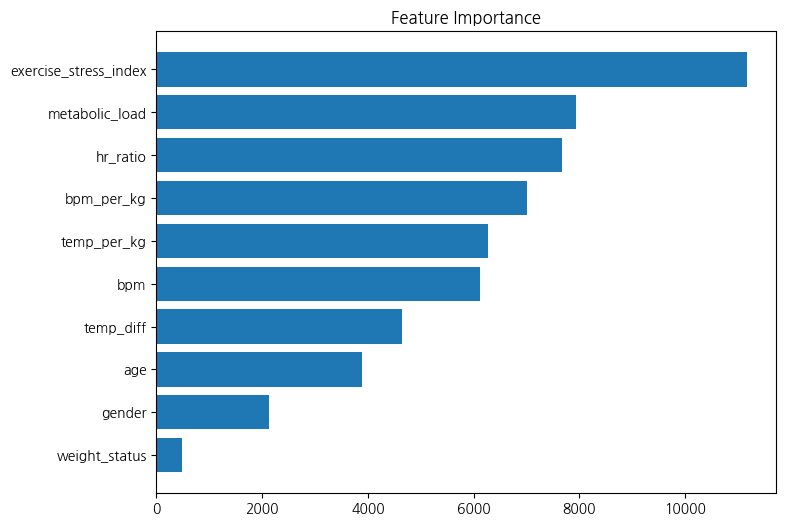

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [ ]:
# LightGBM 파라미터 중요도
fig = plot_param_importances(study_lgbm)
fig.update_layout(title="LightGBM - Parameter Importances", height=500)
fig.show()

In [ ]:
# 테스트 데이터 예측
y_pred = best_model.predict(X_valid)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print(f"Valid RMSE: {rmse:.4f}")
print(f"Valid R2 Score: {r2:.4f}")

In [ ]:
# 과적합 여부 확인: CV RMSE는 좋은데 holdout RMSE가 확 튄다 → 과적합 가능성↑. 비슷하면 문제 없음
pred_valid = best_model.predict(X_valid)
rmse_valid = np.sqrt(np.mean((y_valid - pred_valid)**2))
print(f"Holdout RMSE: {rmse_valid}")

In [ ]:
# 피처 중요도 추출
lgbm = best_model.named_steps["model"]
importances = lgbm.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
# 1) preprocessor 꺼내기
pre = best_model.named_steps["prep"]

# 2) 변환 후 피처명 꺼내기
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    # 구버전 호환: ColumnTransformer 내부에서 OHE만 따로 접근해야 할 수 있음
    feature_names = np.arange(len(best_model.named_steps["model"].feature_importances_)).astype(str)

# 3) 중요도 정렬
lgbm = best_model.named_steps["model"]
importances = lgbm.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(30).to_string(index=False))

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (LightGBM)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# 테스트 데이터 로드
calories_test_data = pd.read_csv("/content/final_test_v10.csv")
calories_test_data.columns = [c.strip() for c in calories_test_data.columns]    # 컬럼명 앞/뒤 공백 제거
X_test = calories_test_data

# 데이터 확인
print(f"데이터 크기: {X_test.shape}")
display(X_test.info())
dup_rows = X_test[X_test.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")

데이터 크기: (7500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   bpm                        7500 non-null   float64
 2   body_temp                  7500 non-null   float64
 3   hr_ratio                   7500 non-null   float64
 4   age                        7500 non-null   int64  
 5   gender                     7500 non-null   object 
 6   height_cm                  7500 non-null   float64
 7   weight_kg                  7500 non-null   float64
 8   bmi                        7500 non-null   float64
 9   log_exercise_stress_index  7500 non-null   float64
 10  log_bsa_intensity_time     7500 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 644.7+ KB


None

중복 확인:
Empty DataFrame
Columns: [ex_dura, bpm, body_temp, hr_ratio, age, gender, height_cm, weight_kg, bmi, log_exercise_stress_index, log_bsa_intensity_time]
Index: []


In [ ]:
# 테스트 데이터 예측
final_pred = best_model.predict(X_test)

In [ ]:
# 제출 파일 제작
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred
submission.to_csv('./submit.csv', index = False, encoding="utf-8")